In [ ]:
! pip install pandas numpy matplotlib seaborn

: 

In [2]:

! pip install scikit-learn

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [5]:
archivos_mat = sorted(glob.glob("*Matrícula*.csv"))
archivos_rend = sorted(glob.glob("*Rendimiento*.csv"))

print("Archivos de Matrícula encontrados:", archivos_mat)
print("Archivos de Rendimiento encontrados:", archivos_rend)

lista_mat = [pd.read_csv(f, sep=";", low_memory=False) for f in archivos_mat]
df_mat = pd.concat(lista_mat, ignore_index=True)

lista_rend = [pd.read_csv(f, sep=";", low_memory=False) for f in archivos_rend]
df_rend = pd.concat(lista_rend, ignore_index=True)

print(f"\nMatrícula consolidada total: {df_mat.shape}")
print(f"Rendimiento consolidado total: {df_rend.shape}")

Archivos de Matrícula encontrados: ['20230906_Matrícula_unica_2023_20230430_WEB.CSV', '20240913_Matrícula_unica_2024_20240430_WEB.CSV', '20250923_Matrícula_unica_2025_20250430_WEB.CSV']
Archivos de Rendimiento encontrados: ['20240209_Rendimiento_2023_20240131_WEB.csv', '20250212_Rendimiento_2024_20250131_WEB.csv', '20260210_Rendimiento_2025_20260202_WEB.csv']

Matrícula consolidada total: (10755848, 38)
Rendimiento consolidado total: (10694240, 38)


In [6]:
import pandas as pd, glob

for f in glob.glob('*.csv'):
    cols = pd.read_csv(f, sep=';', nrows=1, encoding='utf-8-sig').columns
    print(f, len(cols))
    print([c for c in cols if 'RUN' in c or 'ENSE' in c or 'GEN' in c or 'PROM' in c or 'SIT' in c], '\n')

20230906_Matrícula_unica_2023_20230430_WEB.CSV 36
['COD_ENSE', 'COD_ENSE2', 'COD_ENSE3', 'MRUN', 'GEN_ALU'] 

20240209_Rendimiento_2023_20240131_WEB.csv 37
['COD_ENSE', 'COD_ENSE2', 'MRUN', 'GEN_ALU', 'PROM_GRAL', 'SIT_FIN', 'SIT_FIN_R'] 

20240913_Matrícula_unica_2024_20240430_WEB.CSV 37
['COD_ENSE', 'COD_ENSE2', 'COD_ENSE3', 'MRUN', 'GEN_ALU'] 

20250212_Rendimiento_2024_20250131_WEB.csv 38
['COD_ENSE', 'COD_ENSE2', 'MRUN', 'GEN_ALU', 'PROM_GRAL', 'SIT_FIN', 'SIT_FIN_R'] 

20250923_Matrícula_unica_2025_20250430_WEB.CSV 38
['COD_ENSE', 'COD_ENSE2', 'COD_ENSE3', 'MRUN', 'GEN_ALU'] 

20260210_Rendimiento_2025_20260202_WEB.csv 38
['COD_ENSE', 'COD_ENSE2', 'MRUN', 'GEN_ALU', 'PROM_GRAL', 'SIT_FIN', 'SIT_FIN_R'] 

dataset_estudiantes_procesado.csv 10
['COD_ENSE', 'GEN_ALU', 'PROM_GRAL', 'SIT_FIN'] 



In [7]:
# nombrar MRUN a id_estudiante (C3)
import pandas as pd, glob

def cargar(patron, cols):
    return pd.concat(
        (pd.read_csv(f, sep=';', encoding='utf-8-sig', usecols=lambda c: c in cols)
         for f in glob.glob(patron)),
        ignore_index=True
    )

df_mat = cargar('*Matrícula*.csv', ['MRUN', 'AGNO', 'COD_ENSE', 'GEN_ALU']).rename(columns={'MRUN': 'id_estudiante'})
df_rend = cargar('*Rendimiento*.csv', ['MRUN', 'AGNO', 'PROM_GRAL', 'SIT_FIN']).rename(columns={'MRUN': 'id_estudiante'})
df_rend = df_rend.drop_duplicates(['id_estudiante', 'AGNO'])

df_merged = df_mat.merge(df_rend, on=['id_estudiante', 'AGNO'], how='inner')
print(df_merged.shape)

(9775504, 6)


In [8]:
# (c1)
duplicados = df_merged.duplicated().sum()
print(f"Registros duplicados exactos: {duplicados}")

if duplicados > 0:
    df_merged = df_merged.drop_duplicates()
    print("Duplicados eliminados.")

# Reporte de los nulos que se presenta por columna
nulos_df = pd.DataFrame({
    'Nulos': df_merged.isnull().sum(),
    'Porcentaje (%)': (df_merged.isnull().sum() / len(df_merged)) * 100
}).sort_values(by='Nulos', ascending=False)

print("\nTop 10 columnas con mas nulos:")
print(nulos_df.head(10))

Registros duplicados exactos: 0

Top 10 columnas con mas nulos:
               Nulos  Porcentaje (%)
AGNO               0             0.0
COD_ENSE           0             0.0
id_estudiante      0             0.0
GEN_ALU            0             0.0
PROM_GRAL          0             0.0
SIT_FIN            0             0.0


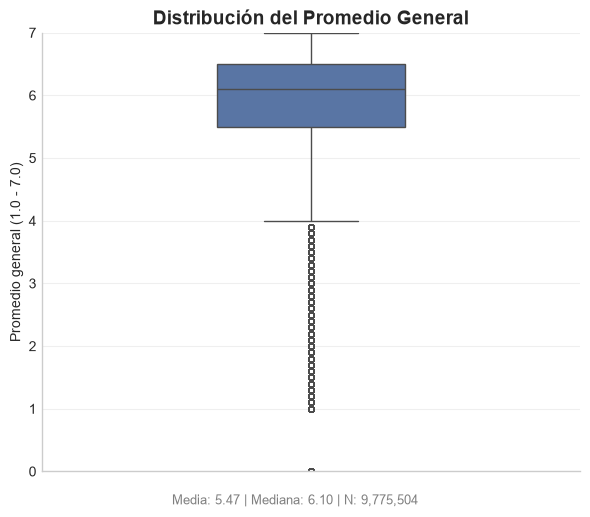

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Convertir la columna a tipo numérico de forma segura
df_merged['PROM_GRAL'] = df_merged['PROM_GRAL'].astype(str).str.replace(',', '.')
df_merged['PROM_GRAL'] = pd.to_numeric(df_merged['PROM_GRAL'], errors='coerce')

# 2. Filtrar datos numéricos válidos
stats = df_merged['PROM_GRAL'].dropna()

plt.figure(figsize=(6, 5))
sns.boxplot(y=stats, color='#4C72B0', width=0.35,
            flierprops=dict(marker='o', markersize=4, markerfacecolor='none', alpha=0.4))
plt.title('Distribución del Promedio General', fontsize=14, fontweight='bold')
plt.ylabel('Promedio general (1.0 - 7.0)')
plt.ylim(0, 7)
plt.grid(axis='y', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)

# 3. Estadísticas clave
media = stats.mean()
mediana = stats.median()
n = len(stats)

texto = f"Media: {media:.2f} | Mediana: {mediana:.2f} | N: {n:,}"
plt.figtext(0.5, -0.02, texto, ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

In [14]:
# c1 continuacion junto con la del grafico de arriba y el 0 de este codigo me sirve para los registros con promedio 0 ya que en chile esa nota no es valida y me entrega el porcentaje en comparado a todos los estudiantes.     
n_ceros = (df_merged['PROM_GRAL'] == 0).sum()
print(f"Casos con PROM_GRAL = 0: {n_ceros:,} ({n_ceros/len(df_merged)*100:.2f}%)")

# Si corresponde a situación de retiro/traslado, revisa SIT_FIN
df_merged[df_merged['PROM_GRAL'] == 0]['SIT_FIN'].value_counts()

Casos con PROM_GRAL = 0: 903,420 (9.24%)


SIT_FIN
Y    479520
P    403956
      11193
R      8751
Name: count, dtype: int64

In [16]:
# Criterio C4: Características Nuevas (Con las columnas REALES de tu DataFrame)
# Columnas disponibles: 'AGNO', 'COD_ENSE', 'id_estudiante', 'GEN_ALU', 'PROM_GRAL', 'SIT_FIN'
import numpy as np

# ------------------------------------------------------------------------------
# Feature 1: Promedio de Notas Normalizado (prom_notas_norm)
# Origen: 'PROM_GRAL'
# Hipótesis: En Mineduc los promedios como 5.5 vienen como enteros (55).
# Normaliza la escala de notas al rango real de 1.0 a 7.0.
# ------------------------------------------------------------------------------
df_merged['prom_notas_norm'] = np.where(
    df_merged['PROM_GRAL'] > 10,
    df_merged['PROM_GRAL'] / 10.0,
    df_merged['PROM_GRAL']
)

# ------------------------------------------------------------------------------
# Feature 2: Riesgo por Rendimiento Académico (riesgo_academico)
# Origen: 'prom_notas_norm'
# Hipótesis: Identifica a estudiantes con nota inferior a 4.0 (reprobación académica).
# ------------------------------------------------------------------------------
df_merged['riesgo_academico'] = (df_merged['prom_notas_norm'] < 4.0).astype(int)

# ------------------------------------------------------------------------------
# Feature 3: Condición Final de Reprobación / Retiro (estudiante_reprobado)
# Origen: 'SIT_FIN' (Donde 'R' = Reprobado, 'P' = Promovido, 'Y' = Retirado, etc.)
# Hipótesis: Convierte la situación final en un indicador binario (1 = No Aprobó, 0 = Aprobó).
# ------------------------------------------------------------------------------
df_merged['estudiante_reprobado'] = np.where(
    df_merged['SIT_FIN'].astype(str).str.upper().isin(['R', 'Y', '2', '3']), 
    1, 
    0
)

# ------------------------------------------------------------------------------
# IMPRESIÓN DE RESULTADOS REALES
# ------------------------------------------------------------------------------
cols_c4 = ['id_estudiante', 'PROM_GRAL', 'prom_notas_norm', 'riesgo_academico', 'SIT_FIN', 'estudiante_reprobado']

print("=== MUESTRA DE DATOS REALES CON CARACTERÍSTICAS NUEVAS ===")
print(df_merged[cols_c4].head(10))

print("\n=== CONTEO DE ESTUDIANTES EN RIESGO ACADÉMICO (Nota < 4.0) ===")
print(df_merged['riesgo_academico'].value_counts())

print("\n=== CONTEO DE ESTUDIANTES REPROBADOS/RETIRADOS (SIT_FIN) ===")
print(df_merged['estudiante_reprobado'].value_counts())

=== MUESTRA DE DATOS REALES CON CARACTERÍSTICAS NUEVAS ===
   id_estudiante  PROM_GRAL  prom_notas_norm  riesgo_academico SIT_FIN  \
0        2090398        0.0              0.0                 1       Y   
1        4360702        5.7              5.7                 0       P   
2        8284609        0.0              0.0                 1       Y   
3        8481824        6.7              6.7                 0       P   
4       14639657        0.0              0.0                 1       Y   
5       23339704        6.3              6.3                 0       P   
6       26921481        6.7              6.7                 0       P   
7       27208038        0.0              0.0                 1       Y   
8         459781        6.4              6.4                 0       P   
9        1580363        0.0              0.0                 1       Y   

   estudiante_reprobado  
0                     1  
1                     0  
2                     1  
3                     

In [18]:

df_merged['prom_notas_norm'] = pd.to_numeric(df_merged['PROM_GRAL'].astype(str).str.replace(',', '.'), errors='coerce')
df_merged['prom_notas_norm_std'] = (df_merged['prom_notas_norm'] - df_merged['prom_notas_norm'].mean()) / df_merged['prom_notas_norm'].std()

#(2)
muy_bajos = df_merged[df_merged['prom_notas_norm_std'] < -2]
print(f"{len(muy_bajos):,} estudiantes ({len(muy_bajos)/len(df_merged)*100:.1f}%)")

# Promedio de nota estandarizada según situación final
print(df_merged.groupby('SIT_FIN')['prom_notas_norm_std'].mean())

# Por género
print(df_merged.groupby('GEN_ALU')['prom_notas_norm_std'].mean())

# Por año
print(df_merged.groupby('AGNO')['prom_notas_norm_std'].mean())

905,746 estudiantes (9.3%)
SIT_FIN
    -2.919632
P    0.180264
R   -0.933539
Y   -2.951543
Name: prom_notas_norm_std, dtype: float64
GEN_ALU
0   -0.691246
1   -0.055970
2    0.059969
Name: prom_notas_norm_std, dtype: float64
AGNO
2023   -0.008411
2024    0.000070
2025    0.008472
Name: prom_notas_norm_std, dtype: float64


In [19]:
df_merged.to_csv("dataset_estudiantes_procesado.csv", index=False, sep=";")
print("Dataset procesado final guardado correctamente.")
print(f"Dimensiones finales: {df_merged.shape}")

Dataset procesado final guardado correctamente.
Dimensiones finales: (9775504, 10)
